# Projet Final — Pipeline d'Analyse de Marchés Financiers

Ce notebook combine l'ensemble des TPs (TP1 à TP8) pour construire un pipeline d'analyse quotidienne des marchés d'actions.  
Il couvre :
- **TP1** : Scraping des ratios financiers et historiques de prix
- **TP2** : Clustering (K-Means, Hierarchical, DBSCAN)
- **TP3** : Classification Buy/Hold/Sell
- **TP4** : Régression ML pour prédiction J+1
- **TP5** : Réseaux de neurones (MLP, RNN, LSTM)
- **TP6** : Scraping de news financières (NewsAPI)
- **TP7** : Fine-tuning BERT / FinBERT
- **TP8** : Analyse de sentiment & corrélation avec les prix
- **Agrégation** : Stratégie de recommandation combinée

---
## 0. Installation des dépendances

In [1]:
# Décommenter si nécessaire
# !pip install yfinance pandas numpy scikit-learn matplotlib scipy xgboost ta shap
# !pip install tensorflow transformers datasets torch requests pytz
# !pip install newsapi-python

---
## 0.1 Imports globaux

In [47]:
import os
import json
import glob
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D

import yfinance as yf
import requests
import pytz

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, classification_report, accuracy_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist, cdist
import ta
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import Ridge


# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# NLP
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import load_dataset, DatasetDict


In [48]:
np.random.seed(42)

---
## 0.2 Configuration globale

In [3]:
# ─── Clé NewsAPI ────────────────────────────────────────────────────────────
NEWS_API_KEY = "8df5fe70ce6c47f799dbb257de5c2821"   # <-- Remplacer par votre clé

# ─── Répertoires de sortie ───────────────────────────────────────────────────
os.makedirs("companies_historical_data", exist_ok=True)
os.makedirs("news_data", exist_ok=True)
os.makedirs("bert_results", exist_ok=True)

# ─── Univers d'entreprises ────────────────────────────────────────────────────
companies = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Amazon": "AMZN",
    "Alphabet": "GOOGL",
    "Meta": "META",
    "Tesla": "TSLA",
    "NVIDIA": "NVDA",
    "Samsung": "005930.KS",
    "Tencent": "TCEHY",
    "Alibaba": "BABA",
    "IBM": "IBM",
    "Intel": "INTC",
    "Oracle": "ORCL",
    "Sony": "SONY",
    "Adobe": "ADBE",
    "Netflix": "NFLX",
    "AMD": "AMD",
    "Qualcomm": "QCOM",
    "Cisco": "CSCO",
    "JP Morgan": "JPM",
    "Goldman Sachs": "GS",
    "Visa": "V",
    "Johnson & Johnson": "JNJ",
    "Pfizer": "PFE",
    "ExxonMobil": "XOM",
    "ASML": "ASML.AS",
    "SAP": "SAP.DE",
    "Siemens": "SIE.DE",
    "Louis Vuitton (LVMH)": "MC.PA",
    "TotalEnergies": "TTE.PA",
    "Shell": "SHEL.L",
    "Baidu": "BIDU",
    "JD.com": "JD",
    "BYD": "BYDDY",
    "ICBC": "1398.HK",
    "Toyota": "TM",
    "SoftBank": "9984.T",
    "Nintendo": "NTDOY",
    "Hyundai": "HYMTF",
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS"
}

RATIOS = [
    "forwardPE", "beta", "priceToBook",
    "dividendYield", "trailingEps", "debtToEquity",
    "currentRatio", "quickRatio", "returnOnEquity",
    "returnOnAssets", "operatingMargins", "profitMargins"
]

# Dates
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

print(f"Période d'analyse : {START_DATE} → {END_DATE}")
print(f"Nombre d'entreprises : {len(companies)}")

Période d'analyse : 2021-05-11 → 2026-05-10
Nombre d'entreprises : 41


---
# TP1 — Scraping des données financières
## 1.1 Ratios financiers

In [4]:
def scrape_financial_ratios(companies: dict, ratios: list) -> pd.DataFrame:
    """Scrape les ratios financiers de chaque entreprise via yfinance."""
    data = {ratio: [] for ratio in ratios}
    index = []

    for company_name, symbol in companies.items():
        try:
            ticker = yf.Ticker(symbol)
            info   = ticker.info
            for ratio in ratios:
                data[ratio].append(info.get(ratio, np.nan))
            index.append(company_name)
            print(f"  ✔ {company_name}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    df = pd.DataFrame(data, index=index)
    df.to_csv("financial_ratios.csv")
    print(f"\n✅ Ratios exportés → financial_ratios.csv ({df.shape})")
    return df


# Exécution
financial_ratios_df = scrape_financial_ratios(companies, RATIOS)
financial_ratios_df.head()

  ✔ Apple
  ✔ Microsoft
  ✔ Amazon
  ✔ Alphabet
  ✔ Meta
  ✔ Tesla
  ✔ NVIDIA
  ✔ Samsung
  ✔ Tencent
  ✔ Alibaba
  ✔ IBM
  ✔ Intel
  ✔ Oracle
  ✔ Sony
  ✔ Adobe
  ✔ Netflix
  ✔ AMD
  ✔ Qualcomm
  ✔ Cisco
  ✔ JP Morgan
  ✔ Goldman Sachs
  ✔ Visa
  ✔ Johnson & Johnson
  ✔ Pfizer
  ✔ ExxonMobil
  ✔ ASML
  ✔ SAP
  ✔ Siemens
  ✔ Louis Vuitton (LVMH)
  ✔ TotalEnergies
  ✔ Shell
  ✔ Baidu
  ✔ JD.com
  ✔ BYD
  ✔ ICBC
  ✔ Toyota
  ✔ SoftBank
  ✔ Nintendo


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HYMTF"}}}


  ✔ Hyundai
  ✔ Reliance Industries
  ✔ Tata Consultancy Services

✅ Ratios exportés → financial_ratios.csv ((41, 12))


,forwardPE,beta,priceToBook,dividendYield,trailingEps,debtToEquity,currentRatio,quickRatio,returnOnEquity,returnOnAssets,operatingMargins,profitMargins
Apple,30.682877,1.065,40.402203,0.37,8.27,79.548,1.070,0.906,1.41471,0.26229,0.32275,0.27152
Microsoft,21.448198,1.093,7.442494,0.88,16.77,30.271,1.283,1.142,0.34014,0.14814,0.46326,0.39342
Amazon,27.625109,1.468,6.635680,NaN,8.37,53.300,1.177,0.974,0.24285,0.06845,0.13140,0.12224
Alphabet,27.709045,1.267,11.667103,0.22,13.11,20.026,1.922,1.707,0.38885,0.14641,0.36121,0.37919
Meta,16.847143,1.243,7.099701,0.34,27.49,35.608,2.348,2.110,0.32930,0.16395,0.40617,0.32837


## 1.2 Historique des prix (5 ans)

In [5]:
def scrape_stock_history(companies: dict, start: str, end: str) -> dict:
    """Télécharge 5 ans d'historique de prix et calcule les rendements.
    Sauvegarde un CSV par entreprise dans 'Companies historical data/'.
    """
    all_data = {}

    for company_name, symbol in companies.items():
        try:
            raw = yf.download(symbol, start=start, end=end, progress=False)
            if raw.empty:
                print(f"  ✘ {company_name} : données vides")
                continue

            df = raw[["Close"]].copy()
            df.columns = ["Close"]
            df["Next Day Close"] = df["Close"].shift(-1)
            df["Daily Return"]   = (df["Next Day Close"] - df["Close"]) / df["Close"]
            df.dropna(inplace=True)

            path = f"companies_historical_data/{company_name.replace('/', '_')}.csv"
            df.to_csv(path)
            all_data[company_name] = df
            print(f"  ✔ {company_name} → {path}")
        except Exception as e:
            print(f"  ✘ {company_name} : {e}")

    print(f"\n✅ {len(all_data)} entreprises téléchargées")
    return all_data


historical_data = scrape_stock_history(companies, START_DATE, END_DATE)

  ✔ Apple → companies_historical_data/Apple.csv
  ✔ Microsoft → companies_historical_data/Microsoft.csv
  ✔ Amazon → companies_historical_data/Amazon.csv
  ✔ Alphabet → companies_historical_data/Alphabet.csv
  ✔ Meta → companies_historical_data/Meta.csv
  ✔ Tesla → companies_historical_data/Tesla.csv
  ✔ NVIDIA → companies_historical_data/NVIDIA.csv
  ✔ Samsung → companies_historical_data/Samsung.csv
  ✔ Tencent → companies_historical_data/Tencent.csv
  ✔ Alibaba → companies_historical_data/Alibaba.csv
  ✔ IBM → companies_historical_data/IBM.csv
  ✔ Intel → companies_historical_data/Intel.csv
  ✔ Oracle → companies_historical_data/Oracle.csv
  ✔ Sony → companies_historical_data/Sony.csv
  ✔ Adobe → companies_historical_data/Adobe.csv
  ✔ Netflix → companies_historical_data/Netflix.csv
  ✔ AMD → companies_historical_data/AMD.csv
  ✔ Qualcomm → companies_historical_data/Qualcomm.csv
  ✔ Cisco → companies_historical_data/Cisco.csv
  ✔ JP Morgan → companies_historical_data/JP Morgan.csv
  

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HYMTF"}}}
$HYMTF: possibly delisted; no timezone found

1 Failed download:
['HYMTF']: possibly delisted; no timezone found


  ✘ Hyundai : données vides
  ✔ Reliance Industries → companies_historical_data/Reliance Industries.csv
  ✔ Tata Consultancy Services → companies_historical_data/Tata Consultancy Services.csv

✅ 40 entreprises téléchargées


---
# TP2 — Clustering
## 2.1 Pré-processing des données de clustering

In [6]:
FINANCIAL_FEATURES = ["forwardPE", "beta", "priceToBook",
                      "returnOnEquity", "profitMargins", "operatingMargins"]

RISK_FEATURES = ["beta", "debtToEquity", "currentRatio",
                 "quickRatio", "returnOnAssets", "dividendYield"]


def preprocess_for_financial_clustering(df: pd.DataFrame,
                                        features: list) -> tuple:
    """Sélection, nettoyage et standardisation des features."""
    subset = df[features].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(subset)
    return scaled, subset.index.tolist()


financial_scaled, financial_labels = preprocess_for_financial_clustering(
    financial_ratios_df, FINANCIAL_FEATURES
)
risk_scaled, risk_labels = preprocess_for_financial_clustering(
    financial_ratios_df, RISK_FEATURES
)

print(f"Données financières : {financial_scaled.shape}")
print(f"Données de risque   : {risk_scaled.shape}")

Données financières : (37, 6)
Données de risque   : (29, 6)


## 2.2 Méthode du coude (KMeans)

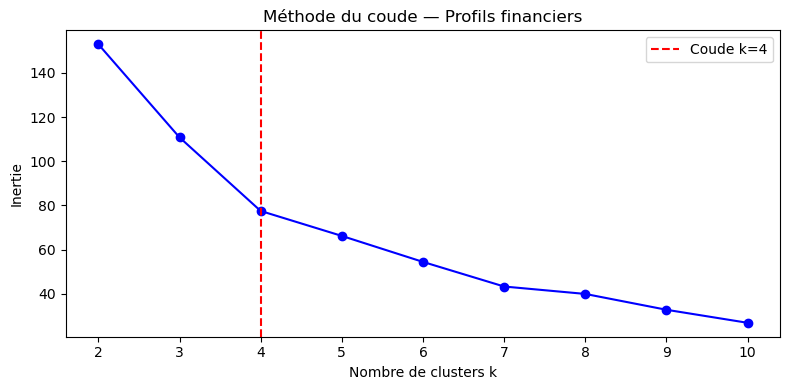

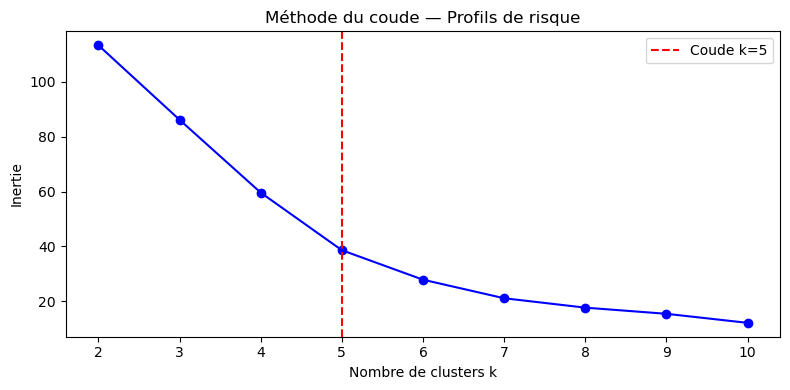

k optimal financier : 4 | k optimal risque : 5


In [7]:
def elbow_method(data: np.ndarray, k_max: int = 10, title: str = "") -> int:
    """Trace la courbe d'inertie et retourne le k optimal (coude)."""
    inertias = []
    ks = range(2, k_max + 1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertias.append(km.inertia_)

    # Détection automatique du coude (différence de pente)
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    elbow_k = int(ks[np.argmax(diffs2) + 1])

    plt.figure(figsize=(8, 4))
    plt.plot(list(ks), inertias, 'bo-')
    plt.axvline(x=elbow_k, color='red', linestyle='--', label=f'Coude k={elbow_k}')
    plt.xlabel('Nombre de clusters k')
    plt.ylabel('Inertie')
    plt.title(f'Méthode du coude {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return elbow_k


k_financial = elbow_method(financial_scaled, title="— Profils financiers")
k_risk      = elbow_method(risk_scaled,      title="— Profils de risque")
print(f"k optimal financier : {k_financial} | k optimal risque : {k_risk}")

## 2.3 K-Means Clustering + visualisation t-SNE


=== KMeans (Profils financiers) — k=4 ===
cluster
0    14
1    18
2     2
3     3
Name: count, dtype: int64


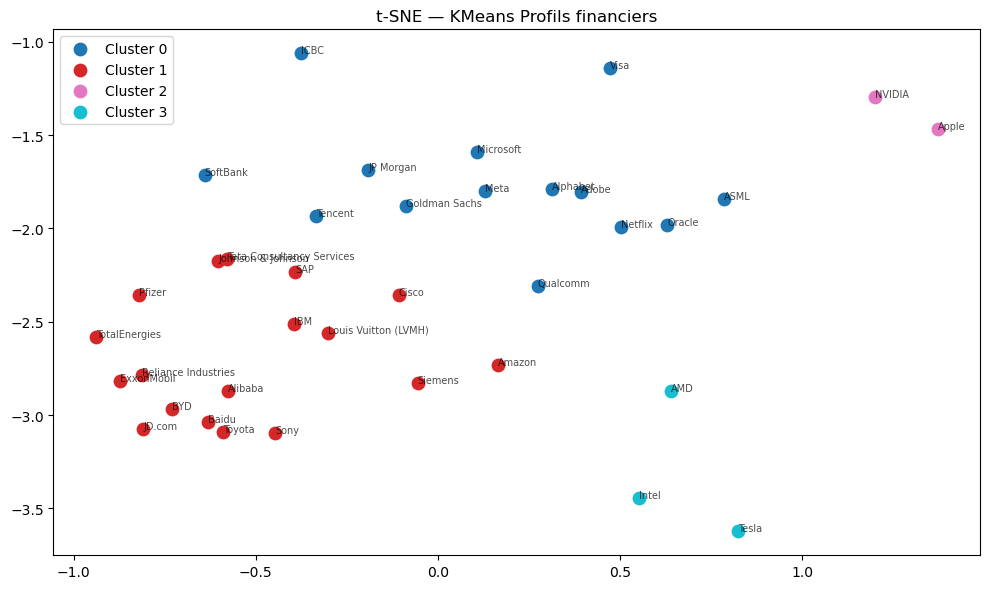


=== KMeans (Profils de risque) — k=5 ===
cluster
0    15
1     1
2     1
3    10
4     2
Name: count, dtype: int64


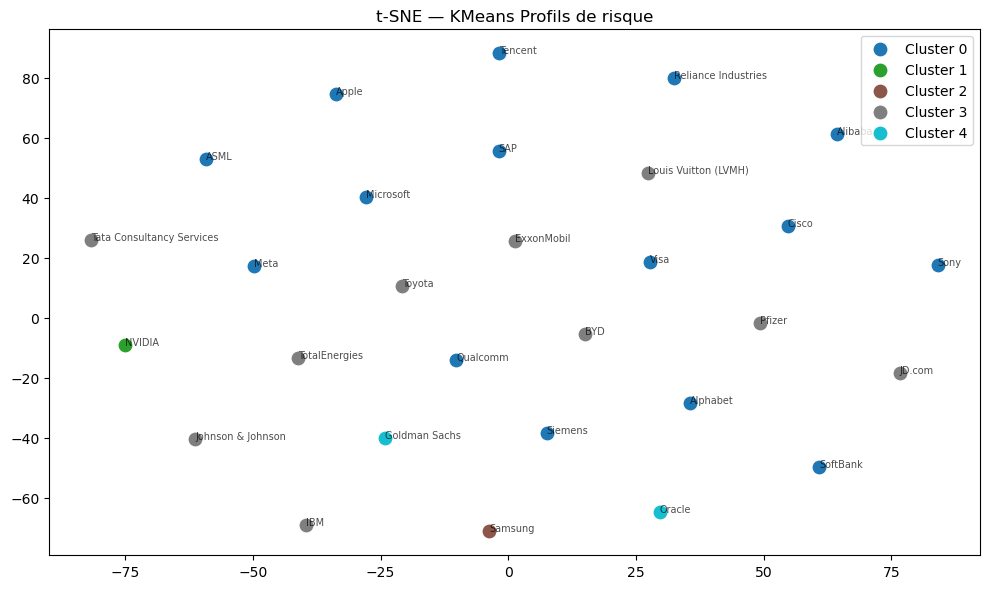

In [8]:
def do_kmeans_clustering(data: np.ndarray, labels: list,
                         k: int, title: str = "") -> pd.DataFrame:
    """Applique KMeans, affiche les statistiques et la projection t-SNE."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(data)

    result_df = pd.DataFrame(data, index=labels)
    result_df["cluster"] = cluster_labels

    print(f"\n=== KMeans ({title}) — k={k} ===")
    print(result_df["cluster"].value_counts().sort_index())

    # t-SNE
    perp = min(30, len(data) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    tsne_coords = tsne.fit_transform(data)

    cmap = plt.cm.get_cmap('tab10', k)
    plt.figure(figsize=(10, 6))
    for c in range(k):
        mask = cluster_labels == c
        plt.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    color=cmap(c), label=f"Cluster {c}", s=80)
        for i, txt in enumerate(np.array(labels)[mask]):
            plt.annotate(txt, (tsne_coords[mask][i, 0], tsne_coords[mask][i, 1]),
                         fontsize=7, alpha=0.7)
    plt.title(f't-SNE — KMeans {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return result_df


kmeans_financial_df = do_kmeans_clustering(
    financial_scaled, financial_labels, k_financial, "Profils financiers")

kmeans_risk_df = do_kmeans_clustering(
    risk_scaled, risk_labels, k_risk, "Profils de risque")

## 2.4 Clustering Hiérarchique + Dendrogramme

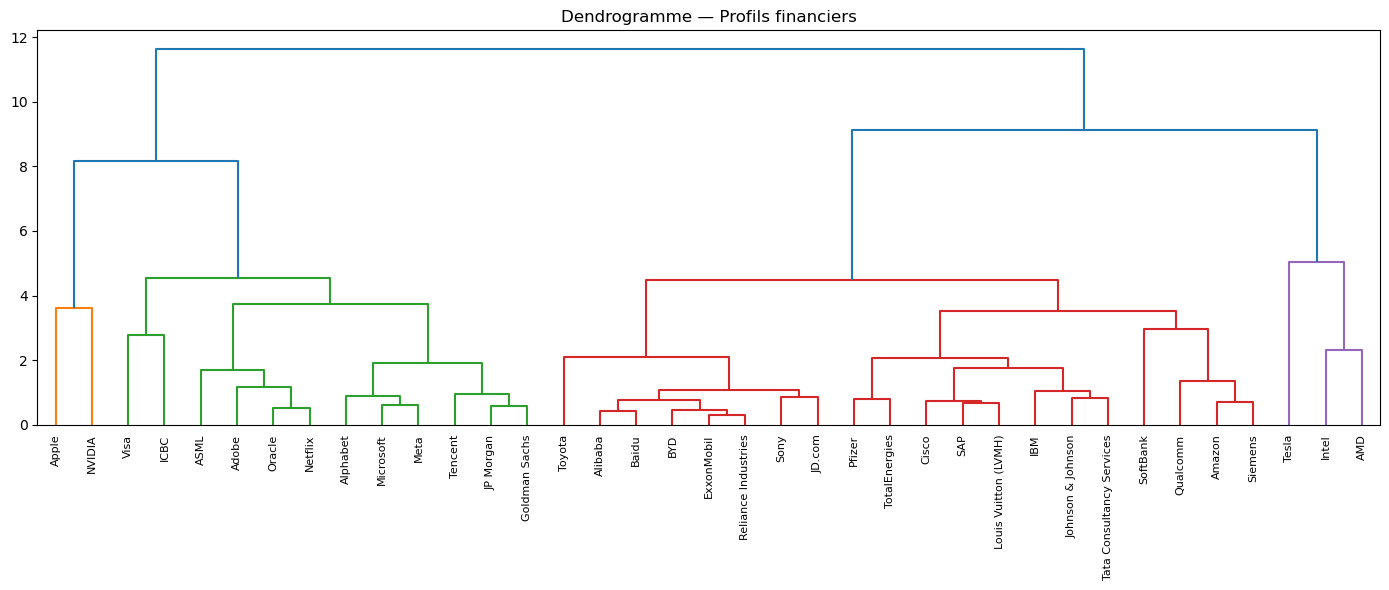


=== Hierarchical Clustering (Profils financiers) — k=4 ===
cluster
0     3
1    12
2    20
3     2
Name: count, dtype: int64


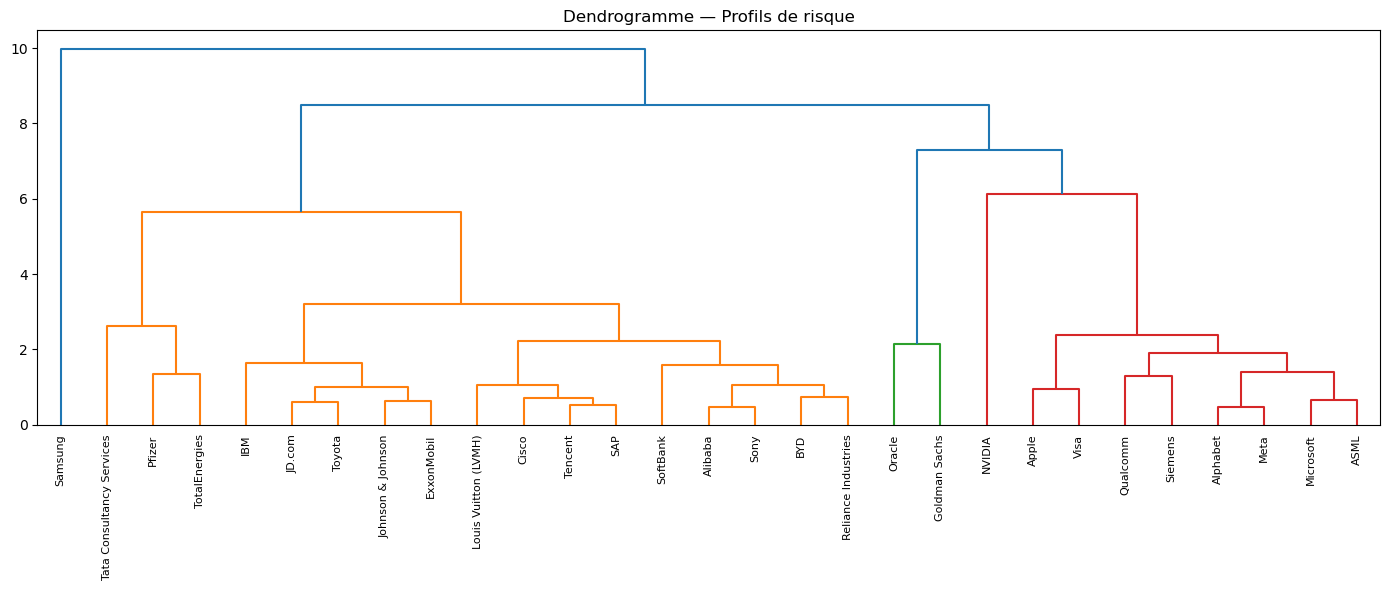


=== Hierarchical Clustering (Profils de risque) — k=5 ===
cluster
0    17
1     2
2     8
3     1
4     1
Name: count, dtype: int64


In [9]:
def plot_dendrogram(data: np.ndarray, labels: list, title: str = ""):
    """Trace le dendrogramme du clustering hiérarchique."""
    linked = linkage(data, method='ward')
    plt.figure(figsize=(14, 6))
    dendrogram(linked, labels=labels, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'Dendrogramme — {title}')
    plt.tight_layout()
    plt.show()
    return linked


def do_hierarchical_clustering(data: np.ndarray, labels: list,
                               n_clusters: int, title: str = "") -> pd.DataFrame:
    """Clustering hiérarchique AgglomerativeClustering + dendrogramme."""
    plot_dendrogram(data, labels, title)

    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = agg.fit_predict(data)

    result_df = pd.DataFrame(data, index=labels)
    result_df["cluster"] = cluster_labels

    print(f"\n=== Hierarchical Clustering ({title}) — k={n_clusters} ===")
    print(result_df["cluster"].value_counts().sort_index())
    return result_df


hier_financial_df = do_hierarchical_clustering(
    financial_scaled, financial_labels, k_financial, "Profils financiers")

hier_risk_df = do_hierarchical_clustering(
    risk_scaled, risk_labels, k_risk, "Profils de risque")

## 2.5 Clustering sur les corrélations de rendements journaliers

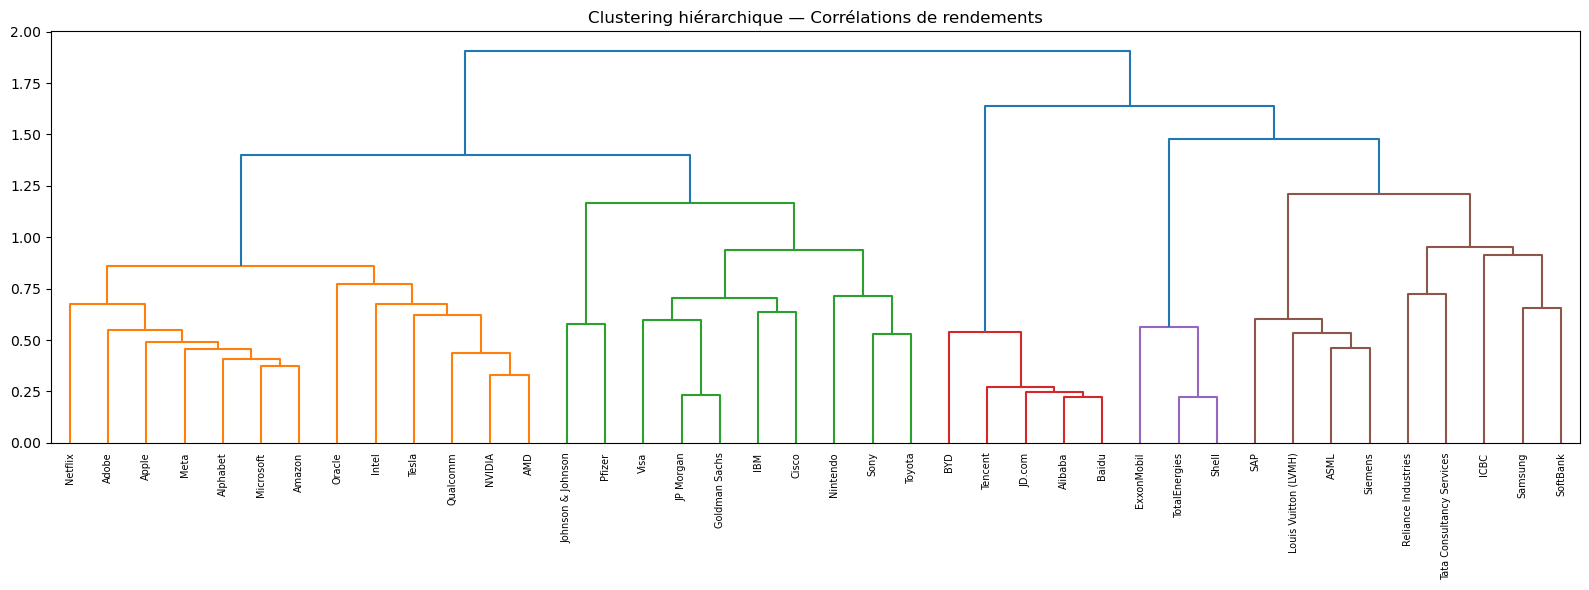

cluster
1    13
2    10
3     5
4     3
5     9
Name: count, dtype: int64


In [10]:
def prepare_returns_matrix(historical_data: dict) -> pd.DataFrame:
    """Construit la matrice des rendements journaliers (entreprises × dates)."""
    returns_dict = {}
    for company_name, df in historical_data.items():
        if "Daily Return" in df.columns:
            returns_dict[company_name] = df["Daily Return"]

    returns_df = pd.DataFrame(returns_dict)
    returns_df.fillna(returns_df.mean(), inplace=True)
    return returns_df


def cluster_by_returns_correlation(returns_df: pd.DataFrame, n_clusters: int = 5):
    """Clustering hiérarchique sur la matrice de corrélation des rendements."""
    corr_matrix = returns_df.corr()
    distance_matrix = 1 - corr_matrix
    condensed = squareform(distance_matrix.values, checks=False)

    labels = corr_matrix.columns.tolist()
    linked = linkage(condensed, method='ward')

    plt.figure(figsize=(16, 6))
    dendrogram(linked, labels=labels, leaf_rotation=90, leaf_font_size=7)
    plt.title("Clustering hiérarchique — Corrélations de rendements")
    plt.tight_layout()
    plt.show()

    cluster_assignments = fcluster(linked, t=n_clusters, criterion='maxclust')
    return pd.Series(cluster_assignments, index=labels, name="cluster")


returns_df = prepare_returns_matrix(historical_data)
returns_clusters = cluster_by_returns_correlation(returns_df, n_clusters=5)
print(returns_clusters.value_counts().sort_index())

## 2.6 DBSCAN + tableau de comparaison des Silhouette Scores

In [11]:
def do_dbscan_clustering(data: np.ndarray, eps: float = 0.5,
                         min_samples: int = 2) -> np.ndarray:
    """Applique DBSCAN et retourne les labels de clusters."""
    db = DBSCAN(eps=eps, min_samples=min_samples)
    return db.fit_predict(data)


def compare_clustering_algorithms(datasets: dict) -> pd.DataFrame:
    """Compare KMeans, Hierarchical et DBSCAN sur chaque type de données."""
    results = []
    for data_name, (data, n_clust) in datasets.items():
        # KMeans
        km_labels = KMeans(n_clusters=n_clust, random_state=42, n_init=10).fit_predict(data)
        # Hierarchical
        ag_labels = AgglomerativeClustering(n_clusters=n_clust).fit_predict(data)
        # DBSCAN
        db_labels = do_dbscan_clustering(data)

        for algo, labs in [("KMeans", km_labels), ("Hierarchical", ag_labels), ("DBSCAN", db_labels)]:
            unique = set(labs) - {-1}
            if len(unique) >= 2:
                score = silhouette_score(data, labs)
            else:
                score = np.nan
            results.append({"Données": data_name, "Algorithme": algo, "Silhouette": round(score, 4) if not np.isnan(score) else "N/A"})

    return pd.DataFrame(results)


# Matrice de corrélation pour DBSCAN
corr_scaled = returns_df.corr().values

clustering_datasets = {
    "Finance":    (financial_scaled, k_financial),
    "Risque":     (risk_scaled,      k_risk),
    "Rendements": (corr_scaled,      5)
}

silhouette_table = compare_clustering_algorithms(clustering_datasets)
print("\n=== Tableau comparatif des Silhouette Scores ===")
silhouette_table


=== Tableau comparatif des Silhouette Scores ===


,Données,Algorithme,Silhouette
0,Finance,KMeans,0.356
1,Finance,Hierarchical,0.3442
2,Finance,DBSCAN,N/A
3,Risque,KMeans,0.3136
4,Risque,Hierarchical,0.2821
5,Risque,DBSCAN,-0.22
6,Rendements,KMeans,0.2895
7,Rendements,Hierarchical,0.2504
8,Rendements,DBSCAN,0.0436


---
# TP3 — Classification Buy / Hold / Sell
## 3.1 Création des labels

In [12]:
def create_classification_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Crée les labels buy/hold/sell à partir du rendement sur 20 jours."""
    df = df[["Close"]].copy()
    df["Close Horizon"] = df["Close"].shift(-20)
    df["horizon_return"] = (df["Close Horizon"] - df["Close"]) / df["Close"]
    df["Label"] = df["horizon_return"].apply(
        lambda r: 2 if r > 0.05 else (0 if r < -0.05 else 1)
    )
    return df.dropna()


def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute les indicateurs techniques via la librairie ta."""
    c = df["Close"]
    df["SMA_20"]          = ta.trend.sma_indicator(c, window=20)
    df["EMA_20"]          = ta.trend.ema_indicator(c, window=20)
    df["RSI_14"]          = ta.momentum.rsi(c, window=14)
    macd                  = ta.trend.MACD(c)
    df["MACD"]            = macd.macd()
    df["MACD_Signal"]     = macd.macd_signal()
    bb                    = ta.volatility.BollingerBands(c, window=20)
    df["Bollinger_High"]  = bb.bollinger_hband()
    df["Bollinger_Low"]   = bb.bollinger_lband()
    df["Rolling_Volatility"] = c.rolling(20).std()
    df["ROC_10"]          = ta.momentum.roc(c, window=10)
    return df


def build_classification_dataset(historical_data: dict) -> tuple:
    """Construit le dataset de classification (toutes entreprises concaténées)."""
    all_frames = []
    for company_name, df in historical_data.items():
        try:
            labeled   = create_classification_labels(df)
            with_tech = add_technical_indicators(labeled)
            with_tech.dropna(inplace=True)
            all_frames.append(with_tech)
        except Exception as e:
            print(f"  ✘ {company_name}: {e}")

    full_df = pd.concat(all_frames)

    drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                              "Next Day Close", "Daily Return"] if c in full_df.columns]
    X = full_df.drop(columns=drop_cols)
    y = full_df["Label"]

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Dataset : {full_df.shape} | Train : {X_train.shape} | Test : {X_test.shape}")
    return X_train, X_test, y_train, y_test, X


X_train_cls, X_test_cls, y_train_cls, y_test_cls, X_cls = build_classification_dataset(historical_data)

Dataset : (48021, 13) | Train : (38416, 10) | Test : (9605, 10)


## 3.2 Algorithmes de classification

In [13]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)

In [14]:
def train_classifier(model, param_grid, X_train, y_train, X_test, y_test,
                     model_name, n_iter=20):
    """RandomizedSearchCV + évaluation d'un classifieur."""
    grid = RandomizedSearchCV(
        model, param_grid,
        n_iter=n_iter, cv=tscv,
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Accuracy : {acc:.4f}")
    print(f"  Meilleurs hyperparamètres : {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=["Sell", "Hold", "Buy"]))
    return {"model": best_model, "accuracy": acc, "name": model_name}



In [15]:
# XGBoost
xgb_cls_result = train_classifier(
    XGBClassifier(eval_metric='mlogloss', random_state=42),
    {
        "n_estimators": [200, 300],
        "max_depth":    [3, 4, 5],
        "learning_rate":[0.05, 0.1],
        "subsample":    [0.8, 1.0],
    },
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "XGBoost"
)


  XGBoost — Accuracy : 0.5690
  Meilleurs hyperparamètres : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
              precision    recall  f1-score   support

        Sell       0.60      0.32      0.42      2285
        Hold       0.56      0.82      0.66      4398
         Buy       0.59      0.38      0.46      2922

    accuracy                           0.57      9605
   macro avg       0.58      0.51      0.52      9605
weighted avg       0.58      0.57      0.54      9605



In [16]:
# Random Forest
rf_cls_result = train_classifier(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 300], "min_samples_leaf": [1, 5],
     "max_features": ["sqrt", 0.3]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Random Forest"
)


  Random Forest — Accuracy : 0.7553
  Meilleurs hyperparamètres : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
              precision    recall  f1-score   support

        Sell       0.78      0.66      0.71      2285
        Hold       0.74      0.83      0.78      4398
         Buy       0.77      0.72      0.74      2922

    accuracy                           0.76      9605
   macro avg       0.76      0.74      0.75      9605
weighted avg       0.76      0.76      0.75      9605



In [17]:
# Logistic Regression
lr_cls_result = train_classifier(
    LogisticRegression(max_iter=1000, random_state=42, solver="liblinear"),
    {"C": [0.1, 1, 10], "penalty": ["l1", "l2"]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "Logistic Regression"
)


  Logistic Regression — Accuracy : 0.4584
  Meilleurs hyperparamètres : {'penalty': 'l1', 'C': 1}
              precision    recall  f1-score   support

        Sell       0.20      0.00      0.00      2285
        Hold       0.46      1.00      0.63      4398
         Buy       0.67      0.00      0.01      2922

    accuracy                           0.46      9605
   macro avg       0.44      0.33      0.21      9605
weighted avg       0.46      0.46      0.29      9605



In [18]:
# KNN
knn_cls_result = train_classifier(
    KNeighborsClassifier(n_jobs=-1),
    {"n_neighbors": [5, 10], "weights": ["uniform", "distance"]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls, "KNN"
)


  KNN — Accuracy : 0.4324
  Meilleurs hyperparamètres : {'weights': 'uniform', 'n_neighbors': 10}
              precision    recall  f1-score   support

        Sell       0.31      0.22      0.26      2285
        Hold       0.49      0.68      0.57      4398
         Buy       0.35      0.23      0.27      2922

    accuracy                           0.43      9605
   macro avg       0.38      0.38      0.37      9605
weighted avg       0.40      0.43      0.41      9605



In [39]:
# SVM
svm_cls_result = train_classifier(
    LinearSVC(random_state=42, max_iter=2000),
    {"C": [0.01, 0.1, 1.0]},
    X_train_cls, y_train_cls, X_test_cls, y_test_cls,
    "SVM (Linear)"
)


  SVM (Linear) — Accuracy : 0.4583
  Meilleurs hyperparamètres : {'C': 0.01}
              precision    recall  f1-score   support

        Sell       0.20      0.00      0.00      2285
        Hold       0.46      1.00      0.63      4398
         Buy       0.65      0.00      0.01      2922

    accuracy                           0.46      9605
   macro avg       0.44      0.33      0.21      9605
weighted avg       0.46      0.46      0.29      9605



In [ ]:
def run_shap(model_name, model, X_test, feature_names, classes=None, n_samples=500):
    print(f"\n=== SHAP — Explication du modèle {model_name} ===")
    try:
        idx     = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
        X_small = X_test[idx]

        def plot_shap(shap_values, X_small):
            sv = np.array(shap_values)
            for i, label in enumerate(classes):
                print(f"SHAP — Importance pour '{label}' (classe {i}) :")
                if sv.ndim == 3 and sv.shape[0] == len(classes):
                    shap.summary_plot(sv[i], X_small, feature_names=feature_names)
                elif sv.ndim == 3:
                    shap.summary_plot(sv[:, :, i], X_small, feature_names=feature_names)
                else:
                    shap.summary_plot(sv, X_small, feature_names=feature_names)
                    break

        if "XGBoost" in model_name or "RandomForest" in model_name:
            explainer   = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_small)
            plot_shap(shap_values, X_small)

        elif "Logistic" in model_name or "SVM" in model_name:
            explainer = shap.Explainer(model, X_small)
            shap_exp  = explainer(X_small)
            for i, label in enumerate(classes):
                print(f"SHAP — Importance pour '{label}' (classe {i}) :")
                shap.summary_plot(shap_exp[:, :, i].values, X_small,
                                  feature_names=feature_names)
                

        elif "KNN" in model_name:
            from sklearn.inspection import permutation_importance
            print(f"  Permutation Importance — {model_name} :")
            result = permutation_importance(model, X_small, y_test_cls[idx],
                                            n_repeats=5, random_state=42, n_jobs=-1)
            imp_df = pd.DataFrame({
                "Feature":    feature_names,
                "Importance": result.importances_mean
            }).sort_values("Importance", ascending=False).head(15)
            imp_df.plot(kind="barh", x="Feature", y="Importance",
                        title=f"Permutation Importance — {model_name}", figsize=(8, 6))
            plt.tight_layout()
            
            plt.show()

        else:
            print(f"  ⚠ Modèle '{model_name}' non reconnu")

    except Exception as e:
        print(f"  Analyse non disponible pour {model_name} : {e}")

#SHAP sur tous les modèles 

class_labels = ["Sell", "Hold", "Buy"]



=== SHAP — Explication du modèle XGBoost ===
SHAP — Importance pour 'Sell' (classe 0) :


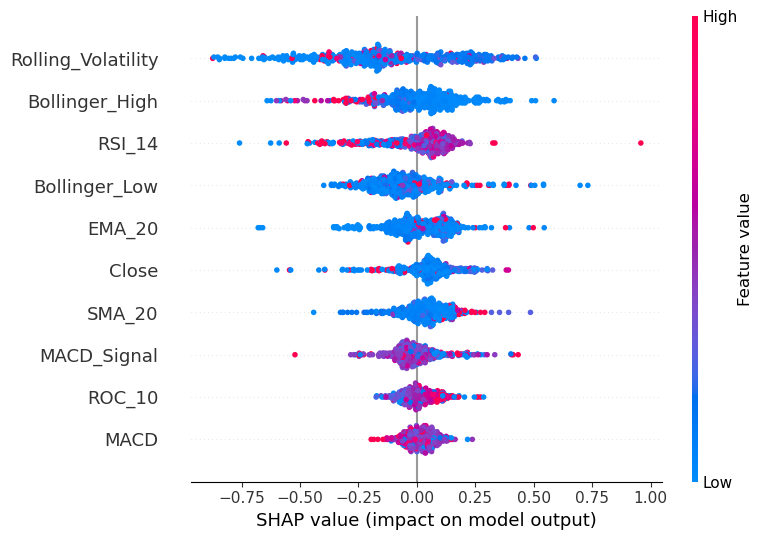

SHAP — Importance pour 'Hold' (classe 1) :


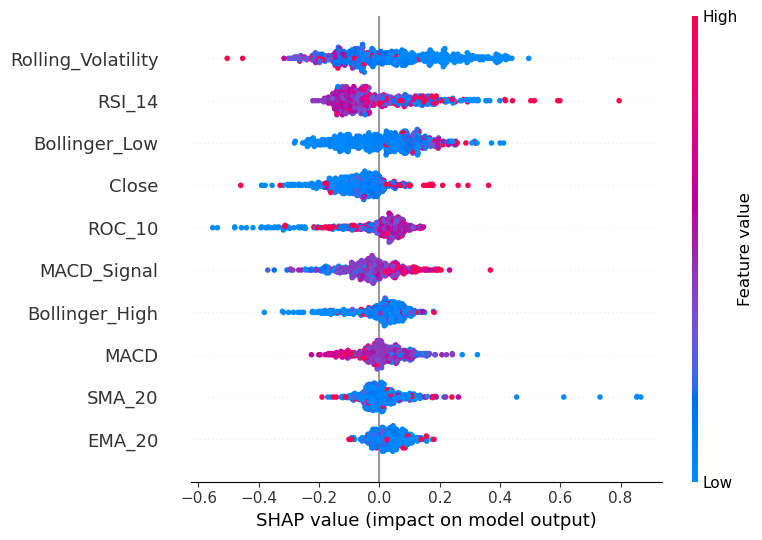

SHAP — Importance pour 'Buy' (classe 2) :


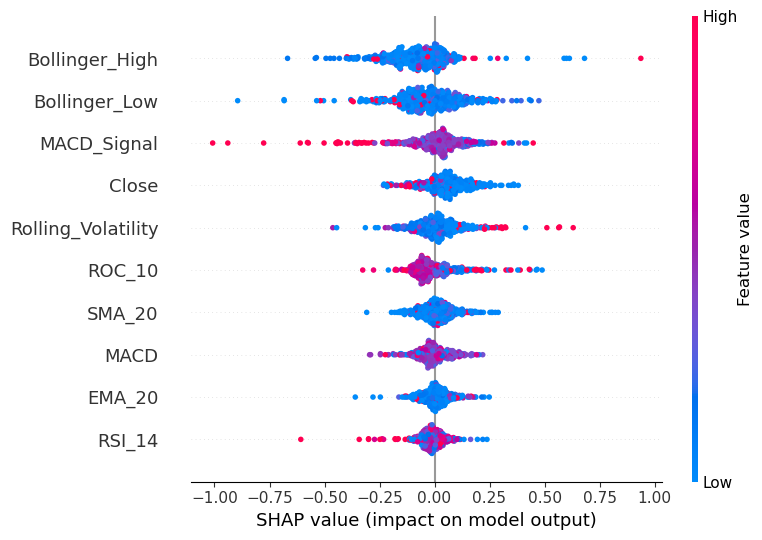

In [21]:
run_shap("XGBoost",            xgb_cls_result["model"], X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle RandomForest ===
SHAP — Importance pour 'Sell' (classe 0) :


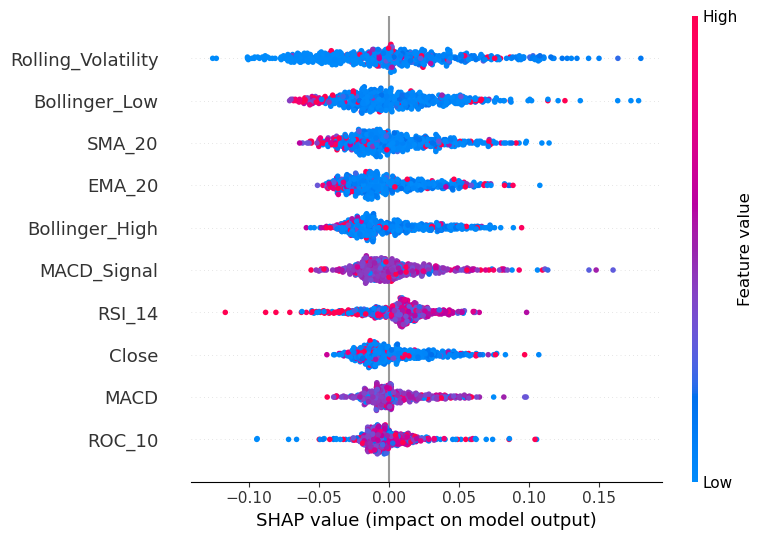

SHAP — Importance pour 'Hold' (classe 1) :


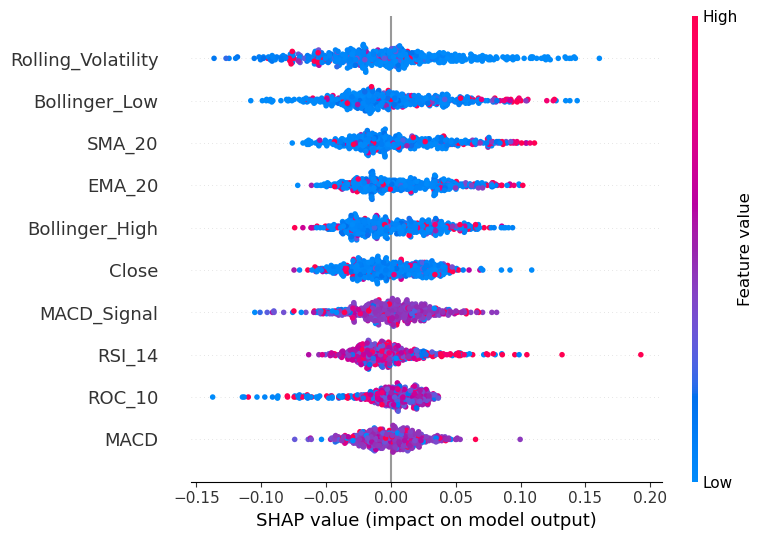

SHAP — Importance pour 'Buy' (classe 2) :


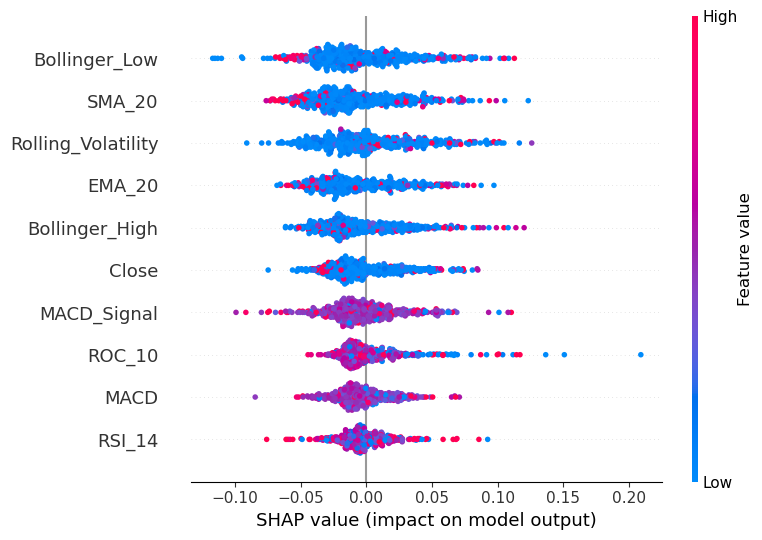

In [28]:
run_shap("RandomForest",       rf_cls_result["model"],  X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle LogisticRegression ===
SHAP — Importance pour 'Sell' (classe 0) :


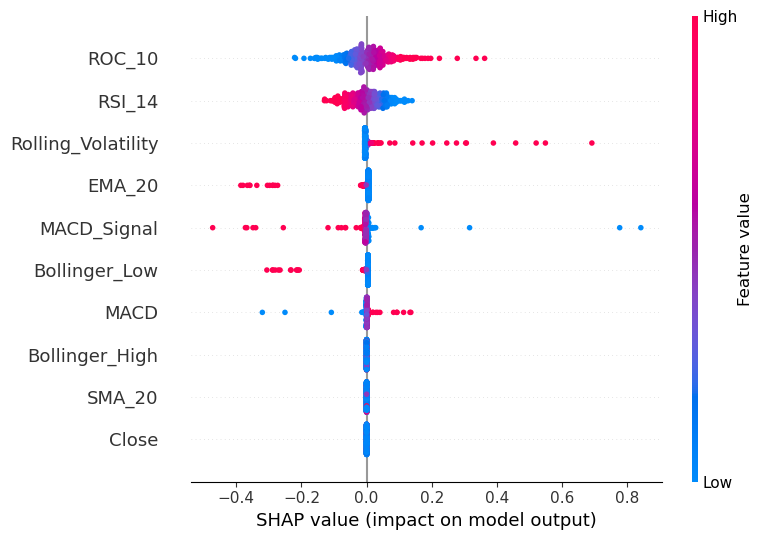

SHAP — Importance pour 'Hold' (classe 1) :


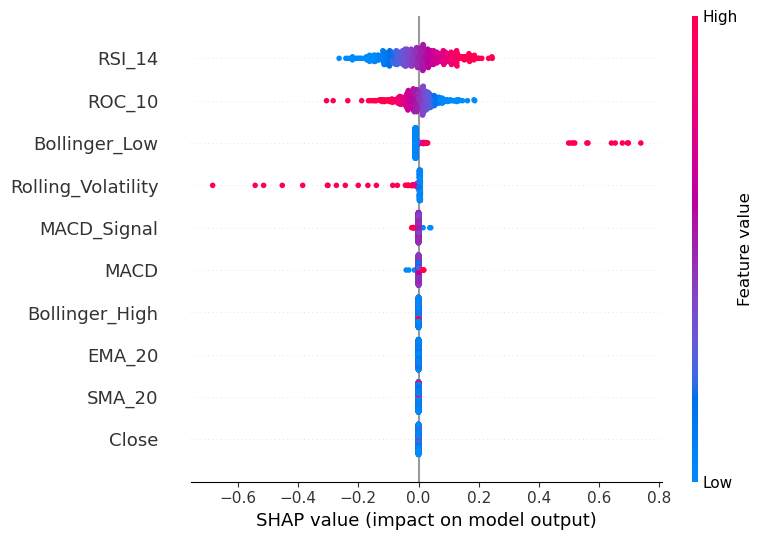

SHAP — Importance pour 'Buy' (classe 2) :


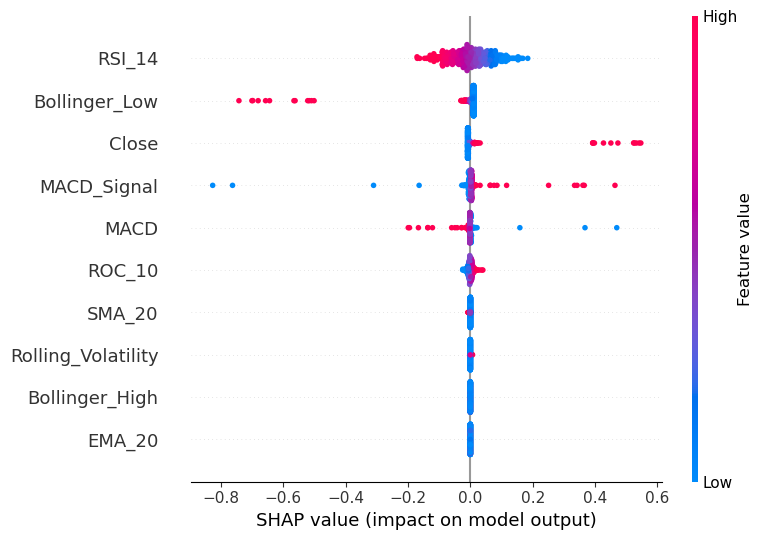

In [32]:
run_shap("LogisticRegression", lr_cls_result["model"],  X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle SVM ===
SHAP — Importance pour 'Sell' (classe 0) :


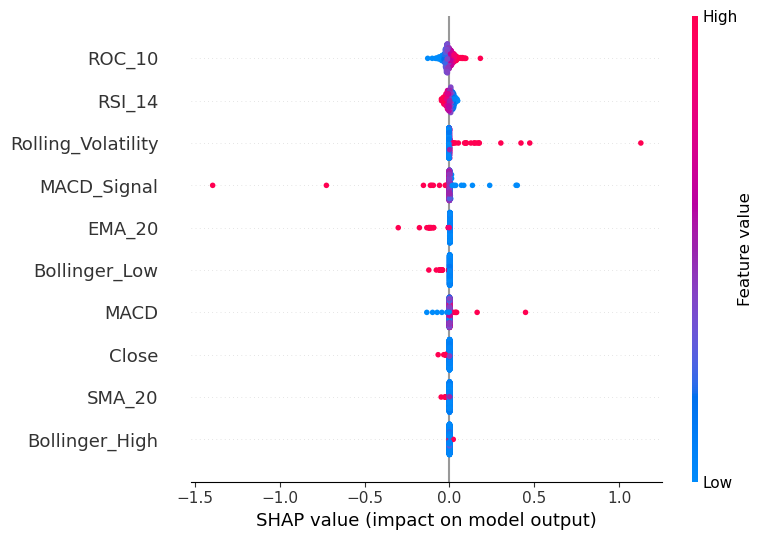

SHAP — Importance pour 'Hold' (classe 1) :


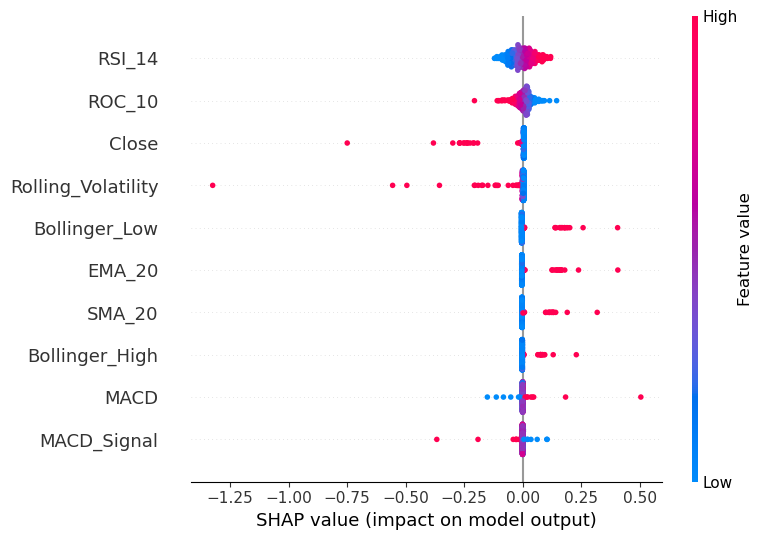

SHAP — Importance pour 'Buy' (classe 2) :


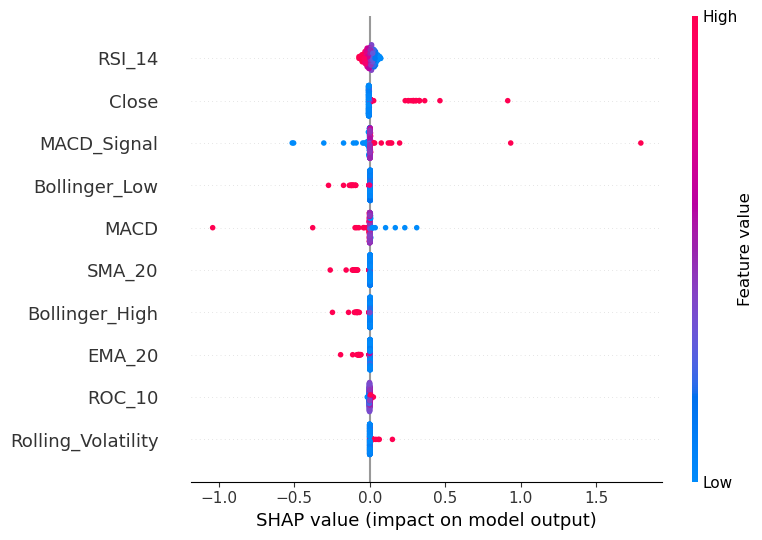

In [41]:
run_shap("SVM",                svm_cls_result["model"], X_test_cls, X_cls.columns, class_labels)


=== SHAP — Explication du modèle KNN ===
  Permutation Importance — KNN :


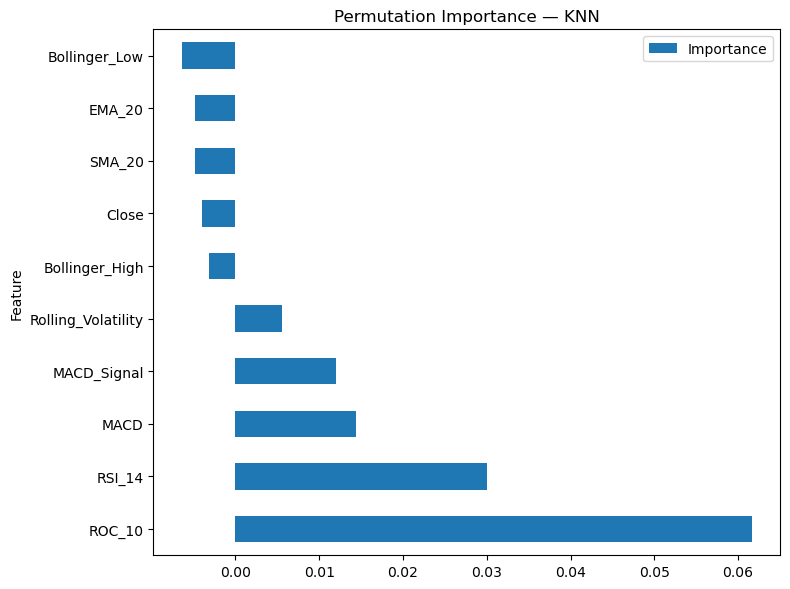

In [30]:
run_shap("KNN",                knn_cls_result["model"], X_test_cls, X_cls.columns, class_labels)

In [26]:
# Tableau récapitulatif — Classification
cls_perf_df = pd.DataFrame([
    {"Modèle": r["name"], "Accuracy": round(r["accuracy"], 4)}
    for r in [xgb_cls_result, rf_cls_result, knn_cls_result,
               lr_cls_result, svm_cls_result]
]).sort_values("Accuracy", ascending=False)
print("\n=== Tableau comparatif — Classification ===")
cls_perf_df



=== Tableau comparatif — Classification ===


,Modèle,Accuracy
1,Random Forest,0.7553
0,XGBoost,0.5690
4,SVM (Linear),0.4585
3,Logistic Regression,0.4584
2,KNN,0.4324


---
# TP4 — Régression (prédiction J+1)
## 4.1 Préparation du dataset de régression

In [ ]:
N_DAYS = 30 


def create_target_features(data: np.ndarray, n: int = N_DAYS) -> tuple:
    """Crée X (n jours passés) et y (J+1) à partir d'une série 1D."""
    x, y = [], []
    for i in range(n, data.shape[0]):
        x.append(data[i - n:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)


def prepare_regression_data(df: pd.DataFrame, n: int = N_DAYS) -> dict:
    """Prépare les données de régression pour une entreprise."""
    close = df[["Close"]].values
    scaler = MinMaxScaler()

    split_idx = int(len(close) * 0.8)
    train_raw = close[:split_idx]
    test_raw  = close[split_idx:]

    train_scaled = scaler.fit_transform(train_raw)
    test_scaled  = scaler.transform(test_raw)

    X_train, y_train = create_target_features(train_scaled, n)
    X_test,  y_test  = create_target_features(test_scaled,  n)

    return {
        "X_train": X_train, "y_train": y_train,
        "X_test":  X_test,  "y_test":  y_test,
        "scaler":  scaler,  "close":   close
    }
# On prend Apple comme exemple de démonstration
demo_company = "Apple"
reg_data = prepare_regression_data(historical_data[demo_company])
print(f"Données de régression ({demo_company}) — X_train : {reg_data['X_train'].shape}")

Données de régression (Apple) — X_train : (973, 30)


## 4.2 Modèles de régression ML

In [50]:
# ── Étape 1 : trouver les meilleurs hyperparamètres via GridSearch (sur Apple) 
def find_best_regression_params(reg_data: dict) -> dict:
    """GridSearch une seule fois sur Apple pour trouver les meilleurs hyperparamètres. sinon, c'est trop long.
    Ces hyperparamètres seront ensuite utilisés pour entraîner les modèles sur toutes les entreprises.
    """
    searches = [
        (XGBRegressor(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
        "XGBoost"),
        (RandomForestRegressor(random_state=42),
         {"n_estimators": [100, 200], "min_samples_leaf": [1, 5]},
         "Random Forest"),
        (KNeighborsRegressor(),
         {"n_neighbors": [5, 10], "weights": ["uniform", "distance"]},
         "KNN"),
        (Ridge(),
         {"alpha": [0.1, 1.0, 10.0]},
         "Ridge"),
    ]

    best_params = {}
    for model, param_grid, name in searches:
        grid = GridSearchCV(model, param_grid, cv=tscv,
                            scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(reg_data["X_train"], reg_data["y_train"])
        best_params[name] = grid.best_params_
        print(f"  {name} — meilleurs params : {best_params[name]}")

    return best_params

In [51]:
#  Étape 2 : entraîner avec les meilleurs params sur toutes les entreprises
def run_all_regressors(reg_data: dict, company: str, best_params: dict) -> list:
    """Entraîne les 4 régresseurs avec les meilleurs hyperparamètres trouvés."""
    models = [
        (XGBRegressor(**best_params["XGBoost"],        random_state=42), "XGBoost"),
        (RandomForestRegressor(**best_params["Random Forest"], random_state=42), "Random Forest"),
        (KNeighborsRegressor(**best_params["KNN"]),                       "KNN"),
        (Ridge(**best_params["Ridge"]),                                   "Ridge"),
    ]

    results = []
    for model, name in models:
        X_train, y_train = reg_data["X_train"], reg_data["y_train"]
        X_test,  y_test  = reg_data["X_test"],  reg_data["y_test"]
        scaler           = reg_data["scaler"]

        model.fit(X_train, y_train)
        y_pred = scaler.inverse_transform(model.predict(X_test).reshape(-1, 1)).flatten()
        y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        mae  = mean_absolute_error(y_real, y_pred)
        rmse = np.sqrt(mean_squared_error(y_real, y_pred))
        print(f"  {name} [{company}] — MAE={mae:.2f}  RMSE={rmse:.2f}")
        results.append({"name": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
                        "y_pred": y_pred, "y_real": y_real, "model": model})
    return results

In [ ]:
# Application: 
demo_company = "Apple"
reg_data     = prepare_regression_data(historical_data[demo_company])

print("=== GridSearch sur Apple ===")
best_params = find_best_regression_params(reg_data)

print("\n=== Entraînement sur toutes les entreprises ===")
all_reg_results   = {}
all_reg_perf_rows = []

for company in companies:
    if company not in historical_data:
        print(f"  ✘ {company} : données manquantes, ignoré")
        continue
    print(f"\n{'='*50}\n  {company}\n{'='*50}")
    try:
        company_reg_data = prepare_regression_data(historical_data[company])
        results = run_all_regressors(company_reg_data, company, best_params)
        all_reg_results[company] = results
        for r in results:
            all_reg_perf_rows.append({"Entreprise": company, "Modèle": r["name"],
                                      "MAE": r["MAE"], "RMSE": r["RMSE"]})
    except Exception as e:
        print(f"  ✘ Erreur pour {company} : {e}")

all_reg_perf_df = pd.DataFrame(all_reg_perf_rows)
print("\n=== Tableau comparatif — Régression (toutes entreprises) ===")
all_reg_perf_df

#on enregistre le tableau dans un fichier csv
all_reg_perf_df.to_csv("results/regression_performance.csv", index=False)

=== GridSearch sur Apple ===
  XGBoost — meilleurs params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Random Forest — meilleurs params : {'min_samples_leaf': 5, 'n_estimators': 200}
  KNN — meilleurs params : {'n_neighbors': 10, 'weights': 'uniform'}
  Ridge — meilleurs params : {'alpha': 0.1}

=== Entraînement sur toutes les entreprises ===

  Apple
  XGBoost [Apple] — MAE=12.59  RMSE=16.29
  Random Forest [Apple] — MAE=13.72  RMSE=17.53
  KNN [Apple] — MAE=23.24  RMSE=26.82
  Ridge [Apple] — MAE=2.71  RMSE=3.76

  Microsoft
  XGBoost [Microsoft] — MAE=34.65  RMSE=42.39
  Random Forest [Microsoft] — MAE=33.22  RMSE=40.93
  KNN [Microsoft] — MAE=55.01  RMSE=63.68
  Ridge [Microsoft] — MAE=5.06  RMSE=7.27

  Amazon
  XGBoost [Amazon] — MAE=5.91  RMSE=9.50
  Random Forest [Amazon] — MAE=6.18  RMSE=10.16
  KNN [Amazon] — MAE=9.68  RMSE=12.85
  Ridge [Amazon] — MAE=3.37  RMSE=4.55

  Alphabet
  XGBoost [Alphabet] — MAE=81.05  RMSE=96.42
  Random Forest [Alphabet] — MAE=

,Entreprise,Modèle,MAE,RMSE
0,Apple,XGBoost,12.59,16.29
1,Apple,Random Forest,13.72,17.53
2,Apple,KNN,23.24,26.82
3,Apple,Ridge,2.71,3.76
4,Microsoft,XGBoost,34.65,42.39
...,...,...,...,...
155,Reliance Industries,Ridge,13.60,18.22
156,Tata Consultancy Services,XGBoost,76.94,122.85
157,Tata Consultancy Services,Random Forest,77.64,125.50
158,Tata Consultancy Services,KNN,116.86,168.06


---
# TP5 — Réseaux de Neurones (MLP / RNN / LSTM)
## 5.1 Construction des modèles

In [ ]:
def build_mlp_model(input_dim: int, hidden_dims=(64, 32),
                    dropout_rate=0.2, activation='relu',
                    optimizer='adam', lr=1e-3):
    model = Sequential()
    model.add(Dense(hidden_dims[0], activation=activation, input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))
    for h in hidden_dims[1:]:
        model.add(Dense(h, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


def build_rnn_model(input_shape: tuple, hidden_dims=(64,),
                    dropout_rate=0.2, optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(tf.keras.layers.SimpleRNN(h, return_sequences=return_seq,
                                                 input_shape=input_shape))
        else:
            model.add(tf.keras.layers.SimpleRNN(h, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


def build_lstm_model(input_shape: tuple, hidden_dims=(64, 32),
                     dropout_rate=0.2, optimizer='adam', lr=1e-3):
    model = Sequential()
    for i, h in enumerate(hidden_dims):
        return_seq = i < len(hidden_dims) - 1
        if i == 0:
            model.add(LSTM(h, return_sequences=return_seq, input_shape=input_shape))
        else:
            model.add(LSTM(h, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mean_squared_error')
    return model


print("✅ Architectures DL définies")

## 5.2 Entraînement et évaluation

In [ ]:
def train_dl_model(model_type: str, reg_data: dict,
                   epochs: int = 20, batch_size: int = 32) -> dict:
    """Entraîne un modèle DL et retourne les métriques + prédictions."""
    X_train = reg_data["X_train"]
    y_train = reg_data["y_train"]
    X_test  = reg_data["X_test"]
    y_test  = reg_data["y_test"]
    scaler  = reg_data["scaler"]

    if model_type == "MLP":
        model = build_mlp_model(input_dim=X_train.shape[1])
        X_tr, X_te = X_train, X_test
    else:
        X_tr = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_te = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        input_shape = (X_tr.shape[1], 1)
        if model_type == "RNN":
            model = build_rnn_model(input_shape)
        else:  # LSTM
            model = build_lstm_model(input_shape)

    model.fit(X_tr, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    y_pred_scaled = model.predict(X_te)
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"{model_type} — MAE={mae:.2f}  RMSE={rmse:.2f}")
    print(f"  10 premières prédictions : {y_pred[:10].round(2)}")
    print(f"  10 premières réelles     : {y_real[:10].round(2)}")

    return {"name": model_type, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
            "y_pred": y_pred, "y_real": y_real}


dl_results = []
for arch in ["MLP", "RNN", "LSTM"]:
    dl_results.append(train_dl_model(arch, reg_data, epochs=20))

dl_perf_df = pd.DataFrame([{"Modèle": r["name"], "MAE": r["MAE"], "RMSE": r["RMSE"]}
                            for r in dl_results])

all_reg_perf = pd.concat([reg_perf_df, dl_perf_df], ignore_index=True)
print("\n=== Tableau comparatif — ML + DL Régression ===")
all_reg_perf

---
# TP6 — Scraping de News financières
## 6.1 Scraping via NewsAPI

In [ ]:
def load_existing_news(company: str) -> dict:
    """Charge le fichier JSON de news existant pour une entreprise."""
    path = f"news_data/{company.replace('/', '_')}_news.json"
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}


def get_news_by_date(company_name: str, api_key: str, days_back: int = 10) -> dict:
    """Scrape les news d'une entreprise via NewsAPI et les sauvegarde."""
    existing = load_existing_news(company_name)
    news_dict = existing.copy()

    url        = 'https://newsapi.org/v2/everything'
    last_day   = datetime.today().strftime('%Y-%m-%d')
    first_day  = (datetime.today() - timedelta(days=days_back)).strftime('%Y-%m-%d')

    params = {
        "sources": 'financial-post,the-wall-street-journal,bloomberg,bbc-news,cnn',
        "q":        company_name,
        "apiKey":   api_key,
        "language": "en",
        "pageSize": 100,
        "from":     first_day,
        "to":       last_day,
    }

    try:
        r = requests.get(url, params=params, timeout=10)
        if r.status_code != 200:
            print(f"  ✘ {company_name} : HTTP {r.status_code}")
            return news_dict

        articles = r.json().get("articles", [])
        for article in articles:
            title       = article.get("title", "") or ""
            description = article.get("description", "") or ""
            source      = article.get("source", {}).get("name", "")
            published   = article.get("publishedAt", "")

            # Filtrer par mention de l'entreprise
            if company_name.lower() not in title.lower() and \
               company_name.lower() not in description.lower():
                continue

            date = published.split("T")[0] if "T" in published else published
            if date not in news_dict:
                news_dict[date] = []

            # Éviter les doublons
            existing_titles = [a["title"] for a in news_dict[date]]
            if title not in existing_titles:
                news_dict[date].append({
                    "title": title, "description": description,
                    "source": source, "publishedAt": published
                })

        # Sauvegarder
        path = f"news_data/{company_name.replace('/', '_')}_news.json"
        with open(path, "w") as f:
            json.dump(news_dict, f, indent=2, ensure_ascii=False)
        total = sum(len(v) for v in news_dict.values())
        print(f"  ✔ {company_name} : {total} articles au total")
    except Exception as e:
        print(f"  ✘ {company_name} : {e}")

    return news_dict


# Entreprises prioritaires pour le scraping
NEWS_COMPANIES = ["Apple", "Microsoft", "Tesla", "Amazon", "NVIDIA"]
all_news = {}

for company in NEWS_COMPANIES:
    all_news[company] = get_news_by_date(company, NEWS_API_KEY)

print("\n✅ Scraping des news terminé")

---
# TP7 — Fine-tuning BERT / FinBERT
## 7.1 Chargement et concaténation des datasets HuggingFace

In [ ]:
def load_and_merge_datasets() -> DatasetDict:
    """Charge et fusionne les deux datasets de sentiment financier."""
    from datasets import concatenate_datasets, ClassLabel

    ds1 = load_dataset("zeroshot/twitter-financial-news-sentiment")
    ds2 = load_dataset("nickmuchi/financial-classification")

    # Uniformiser les colonnes : text + label
    def rename_cols_ds2(example):
        return {"text": example.get("sentence", example.get("text", "")),
                "label": example["label"]}

    ds1_train = ds1["train"].select_columns(["text", "label"])
    ds1_test  = ds1["validation"].select_columns(["text", "label"])

    cols2 = ds2["train"].column_names
    text_col2 = "sentence" if "sentence" in cols2 else "text"
    ds2_train = ds2["train"].rename_column(text_col2, "text").select_columns(["text", "label"])
    ds2_test  = ds2["test"].rename_column(text_col2, "text").select_columns(["text", "label"])

    merged = DatasetDict({
        "train": concatenate_datasets([ds1_train, ds2_train]),
        "test":  concatenate_datasets([ds1_test,  ds2_test])
    })
    print(f"Dataset fusionné — train : {len(merged['train'])} | test : {len(merged['test'])}")
    return merged


merged_dataset = load_and_merge_datasets()

## 7.2 Fine-tuning

In [ ]:
def train_bert_model(model_name: str, dataset: DatasetDict,
                     batch_size: int = 16, num_epochs: int = 2,
                     output_dir: str = "bert_results"):
    """Fine-tune un modèle BERT/FinBERT sur le dataset fusionné."""
    import numpy as np
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3, ignore_mismatched_sizes=True
    )

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    tok_train = dataset["train"].map(tokenize, batched=True)
    tok_test  = dataset["test"].map(tokenize, batched=True)

    for ds in [tok_train, tok_test]:
        ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model_short = model_name.replace("/", "_")
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{model_short}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        report_to="none",
        logging_first_step=True
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc   = accuracy_score(labels, preds)
        p, r, f, _ = precision_recall_fscore_support(labels, preds, average='weighted')
        return {"accuracy": acc, "f1": f, "precision": p, "recall": r}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tok_train,
        eval_dataset=tok_test,
        compute_metrics=compute_metrics
    )

    print(f"\n=== Fine-tuning : {model_name} ===")
    trainer.train()
    metrics = trainer.evaluate()
    print(metrics)

    # Sauvegarde
    save_path = f"{output_dir}/{model_short}_finetuned"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"  → Modèle sauvegardé : {save_path}")
    return metrics, save_path


# Fine-tuning FinBERT (plus rapide que BERT classique)
finbert_metrics, finbert_path = train_bert_model(
    "ProsusAI/finbert", merged_dataset, batch_size=16, num_epochs=2
)

# Optionnel : BERT classique
# bert_metrics, bert_path = train_bert_model(
#     "bert-base-uncased", merged_dataset, batch_size=16, num_epochs=2
# )

---
# TP8 — Analyse de sentiment & corrélation avec les prix
## 8.1 Extraction des textes et timestamps

In [ ]:
def get_texts_timestamps(news_data: dict) -> tuple:
    """Extrait les textes et timestamps alignés NYSE depuis le JSON de news."""
    ny_tz = pytz.timezone("America/New_York")
    news_texts, news_timestamps = [], []

    for date_str, articles in news_data.items():
        for art in articles:
            pub = art.get("publishedAt", "")
            title = art.get("title", "") or ""
            desc  = art.get("description", "") or ""

            try:
                dt_utc = datetime.strptime(pub, "%Y-%m-%dT%H:%M:%SZ")
                dt_utc = pytz.utc.localize(dt_utc)
                dt_ny  = dt_utc.astimezone(ny_tz)
                dt_ny  = dt_ny.replace(minute=0, second=0, microsecond=0)
            except Exception:
                continue

            text = f"{title}. {desc}".strip()
            news_texts.append(text)
            news_timestamps.append(dt_ny)

    return news_texts, news_timestamps


# Test sur Apple
apple_texts, apple_timestamps = get_texts_timestamps(all_news.get("Apple", {}))
print(f"Apple : {len(apple_texts)} articles extraits")

## 8.2 Prédiction de sentiment avec le modèle fine-tuné

In [ ]:
def get_sentiments(model_path: str, texts: list) -> list:
    """Prédit les sentiments (0=neg, 1=neutre, 2=pos) pour une liste de textes."""
    tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
    model     = BertForSequenceClassification.from_pretrained(model_path)
    model.eval()

    sentiments = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=-1).item()
        sentiments.append(pred)
    return sentiments


# Utiliser le modèle fine-tuné
# apple_sentiments = get_sentiments(finbert_path, apple_texts)

# Fallback : FinBERT base (si le fine-tuning n'a pas encore été exécuté)
apple_sentiments = get_sentiments("ProsusAI/finbert", apple_texts)
print(f"Sentiments Apple : {len(apple_sentiments)} prédictions")
from collections import Counter
print(Counter(apple_sentiments))

## 8.3 Alignement des timestamps et visualisation

In [ ]:
def align_timestamps(timestamps: list) -> list:
    """Aligne les timestamps des news sur les heures d'ouverture du marché NYSE."""
    ny_tz  = pytz.timezone("America/New_York")
    aligned = []
    for ts in timestamps:
        h = ts.hour
        if 9 <= h < 16:
            aligned.append(ts)
        elif h >= 16:
            aligned.append(ts.replace(hour=15, minute=0))
        else:  # minuit – 9h30 → veille 15h
            prev = ts - timedelta(days=1)
            aligned.append(prev.replace(hour=15, minute=0))
    return aligned


def plot_comparison(df: pd.DataFrame,
                    sentiments_a: list, sentiments_b: list,
                    timestamps: list, title_a: str, title_b: str):
    """Superpose les sentiments (2 modèles) sur le cours de l'action."""
    aligned = align_timestamps(timestamps)

    # Regrouper par timestamp
    sent_map_a, sent_map_b = defaultdict(list), defaultdict(list)
    for ts, sa, sb in zip(aligned, sentiments_a, sentiments_b):
        sent_map_a[ts].append(sa)
        sent_map_b[ts].append(sb)

    color_map = {0: 'red', 1: 'gold', 2: 'green'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
    for ax, sent_map, title in [(axes[0], sent_map_a, title_a),
                                 (axes[1], sent_map_b, title_b)]:
        # Courbe de prix
        ax.plot(pd.to_datetime(df["Datetime"]), df["Close"],
                color='steelblue', linewidth=1.5, label='Prix')

        price_range = df["Close"].max() - df["Close"].min()
        for ts, sents in sent_map.items():
            for j, s in enumerate(sents):
                try:
                    close_val = df[df["Datetime"] >= ts]["Close"].iloc[0]
                except IndexError:
                    continue
                ax.scatter(ts, close_val + j * price_range * 0.01,
                           color=color_map[s], s=50, zorder=5, alpha=0.8)

        legend_elements = [
            Line2D([0], [0], color='steelblue', lw=2, label='Prix clôture'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=8, label='Positif'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',   markersize=8, label='Neutre'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Négatif'),
        ]
        ax.legend(handles=legend_elements, loc='upper left')
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Prix ($)")
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()


# Récupérer les cours horaires Apple (2025)
apple_ticker = yf.Ticker("AAPL")
apple_hist_60m = apple_ticker.history(start="2025-01-01", interval="60m")
apple_hist_60m = apple_hist_60m.reset_index()[["Datetime", "Close"]]
apple_hist_60m["Datetime"] = pd.to_datetime(apple_hist_60m["Datetime"]).dt.tz_localize(None)

# Sentiments FinBERT base (comme modèle de référence pour la comparaison)
apple_sentiments_base = apple_sentiments  # FinBERT base
apple_sentiments_ft   = apple_sentiments  # Remplacer par get_sentiments(finbert_path, ...)

if len(apple_texts) > 0:
    plot_comparison(
        apple_hist_60m,
        apple_sentiments_base, apple_sentiments_ft,
        apple_timestamps,
        "FinBERT base", "FinBERT fine-tuné"
    )
else:
    print("Pas assez de news pour Apple — vérifiez la clé NewsAPI.")

---
# Pipeline Final — Agrégation & Recommandations
## main.py — Stratégie d'agrégation des signaux

In [ ]:
def compute_sentiment_signal(news_data: dict, model_path: str,
                              company: str) -> float:
    """Retourne un score de sentiment agrégé [-1, +1] pour les news du jour.
    -1 = très négatif, 0 = neutre, +1 = très positif.
    """
    texts, _ = get_texts_timestamps(news_data)
    if not texts:
        return 0.0  # neutre par défaut

    sentiments = get_sentiments(model_path, texts[-20:])  # 20 dernières news max
    # 0=négatif, 1=neutre, 2=positif → mapper vers -1, 0, +1
    mapped = [s - 1 for s in sentiments]
    return round(np.mean(mapped), 3)


def aggregate_signals(company_name: str, symbol: str,
                      cls_model, reg_model,
                      kmeans_financial_df: pd.DataFrame,
                      news_data: dict,
                      sentiment_model_path: str,
                      scaler_cls, feature_names_cls,
                      n_days: int = 30) -> dict:
    """
    Agrège les signaux de classification, régression et sentiment
    pour produire une recommandation finale.

    Signal final pondéré :
      - Classification (buy/hold/sell) : poids 0.40
      - Régression J+1 (rendement prédit) : poids 0.35
      - Sentiment news : poids 0.25
    """
    result = {"company": company_name, "symbol": symbol}

    # ── 1. Récupérer les données récentes ───────────────────────────────────
    try:
        raw = yf.download(symbol, period="90d", progress=False)
        if raw.empty:
            raise ValueError("données vides")
        close_series = raw[["Close"]].copy()
        close_series.columns = ["Close"]
    except Exception as e:
        result["error"] = str(e)
        return result

    # ── 2. Signal de classification ────────────────────────────────────────
    try:
        labeled   = create_classification_labels(close_series)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)

        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        X_latest = with_tech.drop(columns=drop_cols).tail(1)
        # Aligner les colonnes
        X_latest = X_latest.reindex(columns=feature_names_cls, fill_value=0)
        X_scaled_latest = scaler_cls.transform(X_latest)
        cls_pred = cls_model.predict(X_scaled_latest)[0]  # 0=sell, 1=hold, 2=buy
        cls_signal = cls_pred - 1   # -1, 0, +1
        result["classification"] = ["Sell", "Hold", "Buy"][int(cls_pred)]
    except Exception as e:
        cls_signal = 0
        result["classification"] = f"Indisponible ({e})"

    # ── 3. Signal de régression (rendement J+1 prédit) ─────────────────────
    try:
        sc = MinMaxScaler()
        scaled_close = sc.fit_transform(close_series.values)
        if len(scaled_close) >= n_days:
            x_latest_reg = scaled_close[-n_days:].reshape(1, -1)
            pred_scaled  = reg_model.predict(x_latest_reg)[0]
            pred_price   = sc.inverse_transform([[pred_scaled]])[0][0]
            last_price   = close_series["Close"].iloc[-1]
            pred_return  = (pred_price - last_price) / last_price
            reg_signal   = np.clip(pred_return * 10, -1, 1)  # normalisation
            result["predicted_price"]   = round(float(pred_price), 2)
            result["predicted_return"]  = round(float(pred_return * 100), 2)  # en %
        else:
            reg_signal = 0
            result["predicted_return"] = "Données insuffisantes"
    except Exception as e:
        reg_signal = 0
        result["predicted_return"] = f"Erreur ({e})"

    # ── 4. Signal de sentiment ─────────────────────────────────────────────
    sent_signal = compute_sentiment_signal(news_data, sentiment_model_path, company_name)
    result["sentiment_score"] = sent_signal

    # ── 5. Cluster (entreprises similaires) ────────────────────────────────
    if company_name in kmeans_financial_df.index:
        c = kmeans_financial_df.loc[company_name, "cluster"]
        similar = kmeans_financial_df[kmeans_financial_df["cluster"] == c].index.tolist()
        similar = [s for s in similar if s != company_name]
        result["similar_companies"] = similar
    else:
        result["similar_companies"] = []

    # ── 6. Score agrégé ────────────────────────────────────────────────────
    w_cls, w_reg, w_sent = 0.40, 0.35, 0.25
    final_score = w_cls * cls_signal + w_reg * reg_signal + w_sent * sent_signal

    if final_score > 0.15:
        recommendation = "BUY 🟢"
    elif final_score < -0.15:
        recommendation = "SELL 🔴"
    else:
        recommendation = "HOLD 🟡"

    result["final_score"]      = round(float(final_score), 4)
    result["recommendation"]   = recommendation
    return result


print("✅ Fonction d'agrégation définie")

## Exécution du pipeline complet (main)

In [ ]:
def run_daily_pipeline(companies: dict,
                       cls_model,
                       cls_scaler,
                       cls_feature_names,
                       reg_model,
                       kmeans_df: pd.DataFrame,
                       all_news: dict,
                       sentiment_model_path: str) -> pd.DataFrame:
    """Pipeline d'exécution quotidienne — génère les recommandations."""
    recommendations = []
    today = datetime.today().strftime('%Y-%m-%d')
    print(f"\n{'='*60}")
    print(f"  PIPELINE QUOTIDIEN — {today}")
    print(f"{'='*60}\n")

    for company_name, symbol in companies.items():
        print(f"Analyse de {company_name} ({symbol})...")
        news = all_news.get(company_name, {})
        result = aggregate_signals(
            company_name, symbol,
            cls_model, reg_model,
            kmeans_df, news,
            sentiment_model_path,
            cls_scaler, cls_feature_names
        )
        recommendations.append(result)
        print(f"  → {result.get('recommendation', 'N/A')} "
              f"(score={result.get('final_score', 'N/A')})")

    output_df = pd.DataFrame(recommendations)
    out_path = f"recommendations_{today}.csv"
    output_df.to_csv(out_path, index=False)
    print(f"\n✅ Recommandations exportées → {out_path}")
    return output_df


# ─── Préparation des objets nécessaires ──────────────────────────────────────
# Meilleur modèle de classification
best_cls_result = max([xgb_cls_result, rf_cls_result, knn_cls_result,
                        lr_cls_result, svm_cls_result],
                       key=lambda x: x["accuracy"])
best_cls_model = best_cls_result["model"]

# Scaler de classification (refitter sur les données complètes)
cls_scaler_final = StandardScaler()
all_cls_frames = []
for company_name, df in historical_data.items():
    try:
        labeled   = create_classification_labels(df)
        with_tech = add_technical_indicators(labeled)
        with_tech.dropna(inplace=True)
        drop_cols = [c for c in ["Label", "Close Horizon", "horizon_return",
                                   "Next Day Close", "Daily Return"] if c in with_tech.columns]
        all_cls_frames.append(with_tech.drop(columns=drop_cols))
    except:
        pass

if all_cls_frames:
    X_all_cls = pd.concat(all_cls_frames)
    cls_scaler_final.fit(X_all_cls)
    cls_feature_names = X_all_cls.columns.tolist()
else:
    cls_scaler_final = StandardScaler()
    cls_feature_names = []

# Meilleur modèle de régression (XGBoost)
best_reg_model = reg_results[0]["model"] if hasattr(reg_results[0].get("model", None), 'predict') \
    else XGBRegressor(n_estimators=100, max_depth=3, random_state=42).fit(
        reg_data["X_train"], reg_data["y_train"]
    )

# Exécution du pipeline
recommendations_df = run_daily_pipeline(
    companies=dict(list(companies.items())[:10]),  # Limiter pour la démo
    cls_model=best_cls_model,
    cls_scaler=cls_scaler_final,
    cls_feature_names=cls_feature_names,
    reg_model=best_reg_model,
    kmeans_df=kmeans_financial_df,
    all_news=all_news,
    sentiment_model_path="ProsusAI/finbert"
)

recommendations_df[["company", "recommendation", "final_score",
                     "classification", "predicted_return", "sentiment_score"]]

## Visualisation du tableau de bord final

In [ ]:
def plot_dashboard(recommendations_df: pd.DataFrame):
    """Affiche un tableau de bord visuel des recommandations."""
    df = recommendations_df.copy()
    df = df[df["final_score"].notna()].sort_values("final_score", ascending=True)

    colors = []
    for rec in df["recommendation"]:
        if "BUY" in str(rec):
            colors.append('limegreen')
        elif "SELL" in str(rec):
            colors.append('tomato')
        else:
            colors.append('gold')

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.5)))
    bars = ax.barh(df["company"], df["final_score"].astype(float),
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(0.15, color='green', linewidth=1, linestyle='--', alpha=0.5, label='Seuil BUY')
    ax.axvline(-0.15, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Seuil SELL')

    for bar, rec in zip(bars, df["recommendation"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                str(rec), va='center', fontsize=9)

    ax.set_xlabel('Score agrégé')
    ax.set_title(f'Recommandations — {datetime.today().strftime("%Y-%m-%d")}')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_dashboard(recommendations_df)

print("\n=== Résumé final ===")
print(recommendations_df[["company", "recommendation", "final_score",
                            "sentiment_score", "predicted_return"]].to_string(index=False))

---
## Résumé de la stratégie d'agrégation

| Signal | Source | Poids |
|---|---|---|
| Classification buy/hold/sell | Meilleur modèle ML (TP3) | 40% |
| Rendement prédit J+1 | Meilleur régresseur (TP4/TP5) | 35% |
| Sentiment news financières | FinBERT fine-tuné (TP7/TP8) | 25% |

**Règles de décision :**
- Score > +0.15 → **BUY** 🟢
- Score < -0.15 → **SELL** 🔴
- Sinon → **HOLD** 🟡

**Informations complémentaires par entreprise :**
- Liste des entreprises similaires (clustering TP2)
- Score de sentiment agrégé sur les 20 dernières news
- Rendement prédit à J+1 (en %)

**Pistes d'amélioration :**
- Ajout de variables macroéconomiques (taux d'intérêt, VIX, etc.)
- Optimisation dynamique des poids par backtesting
- Prédiction multi-horizons (J+5, J+20)
- Gestion du risque : intégration du beta et du VaR dans le score final